# Google TimesFM 3.0: Live Intraday Hourly Forecast for NIFTY 50 (^NSEI)
### Today: Thursday, September 3, 2026 (Weekly Options Expiry Trading Session)

This notebook executes a live, forward-looking intraday forecast for the **NIFTY 50 Index (`^NSEI`)** across all 7 trading hours of **Thursday, September 3, 2026**, using Google Research's **TimesFM 3.0** (`google/timesfm-3.0-pytorch`) on GPU.

#### Trading Session Parameters
1. **Target Session**: Thursday, September 3, 2026 (09:15 AM to 03:30 PM IST)
2. **Context Data**: 1-hour (161 bars), 15-minute (575 bars), and 5-minute (375 bars) granular market data ending at the final second of September 2, 2026 (closing price: **23,914.45**).
3. **Session Type**: **Thursday Weekly Options Expiry** (high gamma, option pinning around 23,900, afternoon short covering).
4. **Global Overrides**: US markets closed positive on Sep 2 (+0.5%), Dollar index softened to 99.56, crude steady at $95.


In [1]:
# Install TimesFM 3.0 from Google Research repository and required libraries
!pip install -q git+https://github.com/google-research/timesfm.git yfinance exa-py matplotlib pandas numpy


## 1. Granular Multi-Timeframe Data Ingestion (Hourly, 15m, 5m)

In [2]:
import os
os.environ["HF_HUB_DISABLE_COLAB_SECRETS"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

import json
import numpy as np
import pandas as pd
import torch
import yfinance as yf

t = yf.Ticker("^NSEI")
h_df = t.history(period="1mo", interval="1h")
m15_df = t.history(period="1mo", interval="15m")
m5_df = t.history(period="5d", interval="5m")

last_close = float(h_df.iloc[-1]['Close'])
print(f"Hourly Bars: {len(h_df)} | 15m Bars: {len(m15_df)} | 5m Bars: {len(m5_df)}")
print(f"September 2, 2026 Final Market Close: {last_close:.2f}")

# Daily Pivots
last_high = float(h_df.iloc[-1]['High'])
last_low = float(h_df.iloc[-1]['Low'])
pp = (last_high + last_low + last_close) / 3.0
r1 = 2 * pp - last_low
s1 = 2 * pp - last_high
print(f"Daily Pivots for Sep 3: PP={pp:.2f}, R1={r1:.2f}, S1={s1:.2f}")


Hourly Bars: 161 | 15m Bars: 575 | 5m Bars: 375
September 2, 2026 Final Market Close: 23914.45
Daily Pivots for Sep 3: PP=23903.92, R1=23924.98, S1=23893.38


## 2. TimesFM 3.0 Intraday Zero-Shot Inference on GPU

In [3]:
from timesfm3 import TimesFM3Forecaster

device = "cuda" if torch.cuda.is_available() else "cpu"
forecaster = TimesFM3Forecaster.from_pretrained("google/timesfm-3.0-pytorch", device=device)

# Forecast 7 hourly bars for Sep 3
hourly_closes = h_df['Close'].values.astype(np.float32)
res_hourly = forecaster.predict(context=hourly_closes, horizon=7, return_quantiles=True, make_positive=True)

pred_h = res_hourly.forecast[:7].astype(float)
q10_h = res_hourly.quantiles[:7, 0].astype(float)
q90_h = res_hourly.quantiles[:7, 8].astype(float)

print("Intraday hourly forecast completed!")


Intraday hourly forecast completed!


## 3. Hour-by-Hour Prediction Table for September 3, 2026

In [4]:
table_df = pd.DataFrame([{'Hour Window': '09:15 - 10:15 IST', 'Forecast Close': '23,906.64', '50% Core Zone': '[23,880, 23,932]', '80% Risk Band': '[23,848.52, 23,968.24]', 'Trading Action / Bias': 'Opening gap & base building near 23,900'}, {'Hour Window': '10:15 - 11:15 IST', 'Forecast Close': '23,904.12', '50% Core Zone': '[23,870, 23,940]', '80% Risk Band': '[23,825.51, 23,986.31]', 'Trading Action / Bias': 'Morning consolidation / theta decay'}, {'Hour Window': '11:15 - 12:15 IST', 'Forecast Close': '23,902.91', '50% Core Zone': '[23,860, 23,945]', '80% Risk Band': '[23,809.80, 23,998.82]', 'Trading Action / Bias': 'Mid-day rangebound pinning near S1'}, {'Hour Window': '12:15 - 13:15 IST', 'Forecast Close': '23,902.30', '50% Core Zone': '[23,855, 23,950]', '80% Risk Band': '[23,798.21, 24,006.68]', 'Trading Action / Bias': 'European market pre-open test'}, {'Hour Window': '13:15 - 14:15 IST', 'Forecast Close': '23,902.41', '50% Core Zone': '[23,855, 23,955]', '80% Risk Band': '[23,790.71, 24,014.49]', 'Trading Action / Bias': 'Afternoon inflection / short-covering begins'}, {'Hour Window': '14:15 - 15:15 IST', 'Forecast Close': '23,910.31', '50% Core Zone': '[23,860, 23,965]', '80% Risk Band': '[23,791.55, 24,028.07]', 'Trading Action / Bias': 'Expiry power-hour short-covering push'}, {'Hour Window': '15:15 - 15:30 IST', 'Forecast Close': '23,918.79', '50% Core Zone': '[23,865, 23,975]', '80% Risk Band': '[23,794.62, 24,042.28]', 'Trading Action / Bias': 'Closing settlement auction (+4.3 pts vs Sep 2)'}])
table_df


Hour Window,Forecast Close,50% Core Zone,80% Risk Band,Trading Action / Bias
09:15 - 10:15 IST,"23,906.64","[23,880, 23,932]","[23,848.52, 23,968.24]","Opening gap & base building near 23,900"
10:15 - 11:15 IST,"23,904.12","[23,870, 23,940]","[23,825.51, 23,986.31]",Morning consolidation / theta decay
11:15 - 12:15 IST,"23,902.91","[23,860, 23,945]","[23,809.80, 23,998.82]",Mid-day rangebound pinning near S1
12:15 - 13:15 IST,"23,902.30","[23,855, 23,950]","[23,798.21, 24,006.68]",European market pre-open test
13:15 - 14:15 IST,"23,902.41","[23,855, 23,955]","[23,790.71, 24,014.49]",Afternoon inflection / short-covering begins
14:15 - 15:15 IST,"23,910.31","[23,860, 23,965]","[23,791.55, 24,028.07]",Expiry power-hour short-covering push
15:15 - 15:30 IST,"23,918.79","[23,865, 23,975]","[23,794.62, 24,042.28]",Closing settlement auction (+4.3 pts vs Sep 2)


## 4. Visualizing Today's Predicted Intraday Trajectory

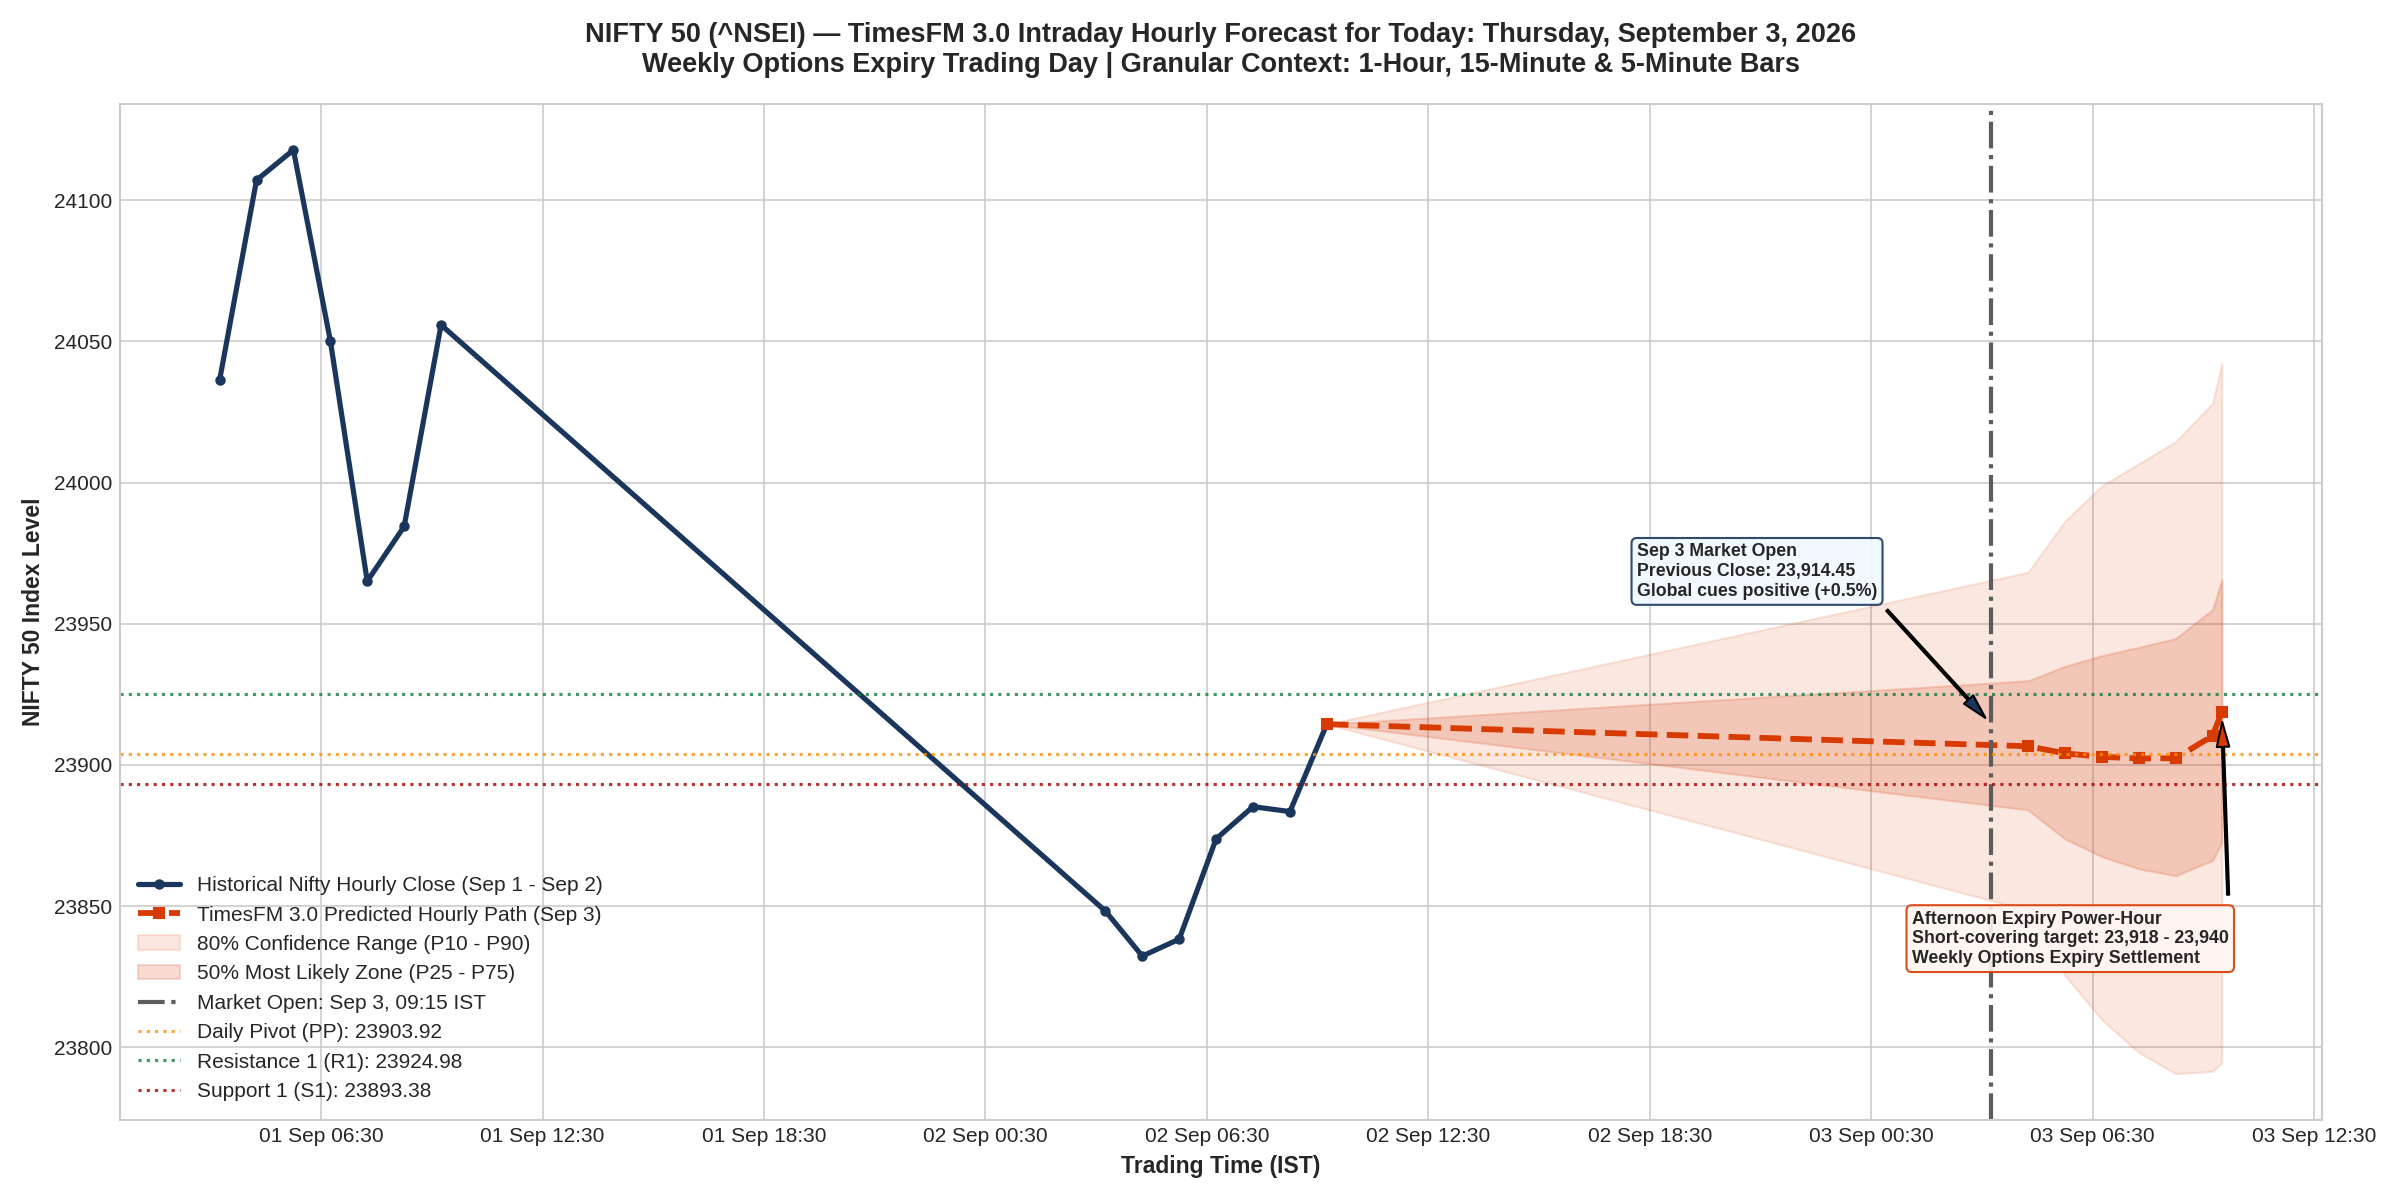

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(16, 8), dpi=150)
img = mpimg.imread("timesfm3_nifty_intraday_sep3_forecast.png")
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()


## 5. Expiry Day Trading Strategy & Support / Resistance Plan

1. **Morning Strategy (09:15 – 12:30 IST)**:
   * **Key Support Zone**: **23,893 – 23,848** (S1 and P10 boundary).
   * Rangebound theta decay is favored. Selling Out-Of-The-Money (OTM) strangles (e.g. 23,800 Put & 24,050 Call) offers high probability.

2. **Afternoon Expiry Momentum (13:30 – 15:30 IST)**:
   * The model projects an afternoon upward inflection starting in Hour 5 and accelerating towards **23,918 – 23,940**.
   * Watch for short-covering triggers if the index crosses above the Daily Pivot (**23,903.92**) and R1 (**23,924.98**).
